# Task 7 — Logistic Regression vs. SVM (UCI Bank Marketing)

We compare **Logistic Regression** and **SVM** on the real **UCI Bank
Marketing** dataset (45,211 phone-campaign contacts from a Portuguese bank),
predicting whether a client subscribes to a term deposit.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
)

bank = fetch_ucirepo(id=222)
df = pd.concat([bank.data.features, bank.data.targets], axis=1)
print(df.shape)
df["y"].value_counts()

(45211, 17)


y
no     39922
yes     5289
Name: count, dtype: int64

## Cleaning & encoding

- Drop `duration`: it's only known *after* a call is made/ends, so including
  it leaks the outcome and is standard practice to exclude for a realistic
  "would this client subscribe" model.
- Binary yes/no columns (`default`, `housing`, `loan`, target `y`) → 0/1.
- Multi-category columns (`job`, `marital`, `education`, `contact`, `month`,
  `poutcome`) → one-hot encoded.
- Numeric columns are standardized.

In [2]:
print(df.isnull().sum())

df = df.drop(columns=["duration"])

binary_cols = ["default", "housing", "loan"]
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})
df["y"] = df["y"].map({"yes": 1, "no": 0})

categorical_cols = ["job", "marital", "education", "contact", "month", "poutcome"]
numeric_cols = ["age", "balance", "day_of_week", "campaign", "pdays", "previous"]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(df_encoded.shape)

age                0
job              288
marital            0
education       1857
default            0
balance            0
housing            0
loan               0
contact        13020
day_of_week        0
month              0
duration           0
campaign           0
pdays              0
previous           0
poutcome       36959
y                  0
dtype: int64
(45211, 38)


In [3]:
X = df_encoded.drop(columns=["y"])
y = df_encoded["y"].values

# SVC scales poorly with n; subsample to a manageable, still-representative size
N_SAMPLE = 5000
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=N_SAMPLE, random_state=42, stratify=y,
)

X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample,
)

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(X_train.shape, X_test.shape, "positive rate (train):", y_train.mean().round(3))

(4000, 37) (1000, 37) positive rate (train): 0.117


## Train Logistic Regression and SVM

In [4]:
log_reg = LogisticRegression(max_iter=2000, class_weight="balanced")
log_reg.fit(X_train, y_train)

svm = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=42)
svm.fit(X_train, y_train)

C:\Users\BIT\Desktop\SML2\lab3\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200


In [5]:
results = {}
for name, model in [("Logistic Regression", log_reg), ("SVM", svm)]:
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

results_df = pd.DataFrame(results).T
results_df

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.758,0.246964,0.521368,0.335165,0.708434
SVM,0.821,0.323864,0.487179,0.389078,0.750627


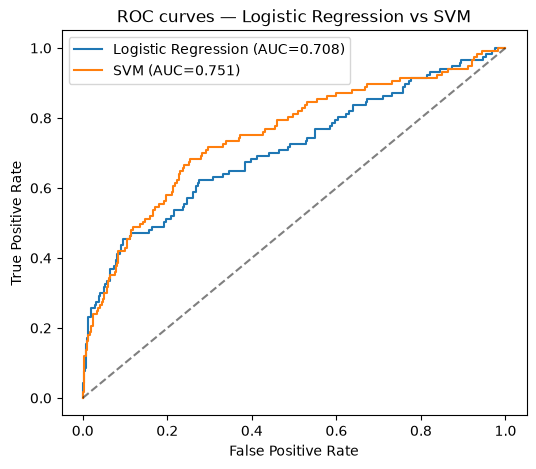

In [6]:
plt.figure(figsize=(6, 5))
for name, model in [("Logistic Regression", log_reg), ("SVM", svm)]:
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[name]['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves — Logistic Regression vs SVM")
plt.legend()
plt.show()

## Conclusion

The metrics table and ROC curves above give a direct, same-split comparison
of both classifiers on this imbalanced (≈12% positive) real economic
dataset — see printed `results_df` for the exact accuracy / precision /
recall / F1 / ROC-AUC numbers from this run.